In [ ]:
# Install required packages
!pip install pyLDAvis
!pip install gensim
!pip install scikit-learn
!pip install nltk
!pip install tqdm

# Graph-Based Method

## Import libraries

In [1]:
import os
import re
import string
import tarfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from pathlib import Path
from tqdm import tqdm

# NLTK
import nltk
'''nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')'''
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

# Gensim
from gensim.models.phrases import Phrases
from gensim import models, corpora
from gensim.models.ldamodel import LdaModel
from gensim.models import CoherenceModel, LsiModel

# Sklearn
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import TruncatedSVD, NMF
from sklearn.metrics.pairwise import cosine_similarity

# Visualization
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

/usr/local/lib/python3.12/dist-packages/google/cloud/aiplatform/models.py:52: FutureWarning: Support for google-cloud-storage < 3.0.0 will be removed in a future version of google-cloud-aiplatform. Please upgrade to google-cloud-storage >= 3.0.0.
  from google.cloud.aiplatform.utils import gcs_utils


## Import Data

In [2]:
print("\n" + "="*60)
print("EXTRACTING CNN STORIES DATA")
print("="*60)

# Your correct path
INPUT_PATH = '/kaggle/input/cnn-stories/cnn_stories.tgz'
OUTPUT_PATH = '/kaggle/working/cnn_stories_data'

# Extract the .tgz file
with tarfile.open(INPUT_PATH, 'r:gz') as tar:
    print("Extracting... (this may take a few minutes)")
    tar.extractall(OUTPUT_PATH)

print("✓ Extraction complete!")

# Check extracted contents
print("\nExtracted contents:")
print(os.listdir(OUTPUT_PATH))

# Count story files
for root, dirs, files in os.walk(OUTPUT_PATH):
    level = root.replace(OUTPUT_PATH, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    story_count = len([f for f in files if f.endswith('.story')])
    if story_count > 0:
        print(f'{indent}  → {story_count} .story files')


EXTRACTING CNN STORIES DATA
Extracting... (this may take a few minutes)
✓ Extraction complete!

Extracted contents:
['cnn']
cnn_stories_data/
  cnn/
    stories/
      → 92579 .story files


In [3]:
print("\n" + "="*60)
print("FINDING AND PARSING STORY FILES")
print("="*60)

def find_story_files(base_path):
    """Find all .story files in the directory"""
    story_files = []
    for root, dirs, files in os.walk(base_path):
        for file in files:
            if file.endswith('.story'):
                story_files.append(os.path.join(root, file))
    return story_files

story_files = find_story_files('cnn_stories_data')
print(f"Total .story files found: {len(story_files)}")

def parse_story_file(file_path):
    """Parse a CNN .story file into article and highlights"""
    with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
        content = f.read()


 # Split by @highlight
    parts = content.split('@highlight')

    # First part = Article
    article = parts[0].strip()

    # Remaining parts = Highlights (summary)
    highlights = [h.strip() for h in parts[1:] if h.strip()]
    summary = ' . '.join(highlights)

    return {
        'article': article,
        'highlights': summary,
        'highlight_list': highlights,
        'num_highlights': len(highlights)
    }


# Test with one file
sample = parse_story_file(story_files[0])
print("\nSample article preview:")
print(sample['article'][:300] + "...")


FINDING AND PARSING STORY FILES
Total .story files found: 92579

Sample article preview:
(CNN)Talk about a "Modern Family."

Wednesday night's "Modern Family" was shot entirely using Apple products. Titled "Connection Lost," the episode revolved around the family communicating via all of Apple's devices -- iPhones, iPads and a MacBook.

During the ABC show, character Claire Dunphy uses ...


In [4]:
print("\n" + "="*60)
print("LOADING ALL CNN STORIES")
print("="*60)

def load_cnn_stories(story_files, limit=None):
    """Load .story files into DataFrame"""
    if limit:
        story_files = story_files[:limit]

    data_list = []
    print(f"Loading {len(story_files)} stories...")

    for file_path in tqdm(story_files):
        try:
            parsed = parse_story_file(file_path)
            parsed['filename'] = os.path.basename(file_path)
            data_list.append(parsed)
        except:
            continue

    return pd.DataFrame(data_list)
data_cnn = load_cnn_stories(story_files, limit=None)

print(f"\n✓ Loaded {len(data_cnn)} stories")
display(data_cnn.head())


LOADING ALL CNN STORIES
Loading 92579 stories...


100%|██████████| 92579/92579 [00:03<00:00, 25493.05it/s]



✓ Loaded 92579 stories


,article,highlights,highlight_list,num_highlights,filename
0,"(CNN)Talk about a ""Modern Family.""\n\nWednesda...",Wednesday's show was shot using all Apple prod...,[Wednesday's show was shot using all Apple pro...,3,fb310a7cc97be49363c7a49870f302fdb3f8e50f.story
1,"WASHINGTON (CNN) -- More than 35,000 fugitives...",U.S. marshals team with local law enforcement ...,[U.S. marshals team with local law enforcement...,4,7d29852cecf995651bdae06b86f75d03fbf59989.story
2,NEW YORK (CNN) -- Even the most banal question...,"""Flight of the Conchords"" is offbeat musical-c...","[""Flight of the Conchords"" is offbeat musical-...",3,9af321faea573efffd198ef4b3db0635c50701e6.story
3,"This week, as the Senate decides whether to re...",Leslie Steiner: Victims of domestic violence j...,[Leslie Steiner: Victims of domestic violence ...,4,60b4fe161f8d5cefcba3a0e8ffb0f4145eb31df0.story
4,Editor's note: Joel I. Klein has been chancell...,Joel I Klein: Caroline Kennedy one of few will...,[Joel I Klein: Caroline Kennedy one of few wil...,4,369c1b274ad90544e742d60ee12e71971c21c631.story


In [ ]:
data_cnn.tail(50)

In [5]:
!pip install contractions
!pip install rouge

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 6.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.7 MB/s eta 0:00:00


In [6]:
import re
from functools import partial
# one time execution
#nltk.download('punkt_tab')
#nltk.download('omw-1.4')

from sklearn.feature_extraction.text import HashingVectorizer
import networkx
import matplotlib.pyplot as plt
%matplotlib inline

from textwrap import wrap

import contractions
import gensim
import rouge
import difflib
import seaborn as sns
from IPython.core.display import display, HTML

In [7]:
DOCUMENT = 'Comedian Joan Rivers died of "therapeutic complications" during a procedure to evaluate her "voice changes" and stomach reflux, the New York medical examiner said Thursday.\n\n"The classification of a death as a therapeutic complication means that the death resulted from a predictable complication of medical therapy," the report said.\n\n Rivers, 81, died September 4, a week after an appointment at Manhattan\'s Yorkville Endoscopy clinic.\n\n The medical examiner\'s investigation ruled that the cause of death was "anoxic encephalopathy due to hypoxic arrest," a medical description of brain damage caused by a lack of oxygen.\n\n The arrest happened "during laryngoscopy and upper gastrointestinal endoscopy with propofol sedation for evaluation of voice changes and gastroesophageal reflux disease," the medical examiner\'s officer said.\n\n The complication in this case was laryngospasm -- a spasm of the vocal cords that makes it difficult to breathe, pathologist and surgeon Bill Lloyd told CNN. The situation was compounded when Rivers went into cardiac arrest.\n\n"She stopped breathing and her heart went into arrhythmia because there wasn\'t sufficient oxygen to maintain the heart muscle," said Lloyd, who was not involved in Rivers\' autopsy. "The pump, the heart itself, was unable to move fresh oxygenated blood upstream to the brain."\n\n At first, Lloyd said, Rivers was unable to bring oxygen into her body due to the vocal cord spasm. After a couple of minutes, her heart started to beat irregularly or completely stopped. Finally, her heart stopped delivering fresh oxygenated blood to her brain, which shut down, according to Lloyd.\n\n"The unanswered question is why they did not do a combat (tracheotomy)?" he asked. "You\'ve seen in the James Bond movies. You take a ballpoint pen and puncture the thyroid cartilage and create an emergency airway for her. Of course, they would do it with sterile instruments. ... And, after minute two, did anybody say, We need to start doing some CPR for her?"\n\n The initial report did not name the doctor or doctors who performed the procedures.\n\n Melissa Rivers posted this on Twitter on Friday afternoon: "In response to NYC\'s Medical examiner\'s report, we continue to be saddened by our tragic loss. No further comment at this time."\n\n Timeline emerges in Joan Rivers\' death\n\n What happened?\n\n Several clinic workers told investigators that the August 28 appointment began with Rivers\' personal throat doctor, Dr. Gwen Korovin, performing a laryngoscopy, which involves using a device to view a patient\'s vocal folds, a source close to the investigation told CNN last month.\n\n Gastroenterologist Dr. Lawrence Cohen, who was the medical director of the clinic until resigning after Rivers\' death, then performed an endoscopy intended to diagnose why she was suffering a sore throat and hoarseness, the source said.\n\n Cohen detected something of concern, the source said.\n\n Korovin then began a second laryngoscopy to again view River\'s vocal cords, the source said. It was at that time that her vocal cords began to swell, leading to a cutoff of oxygen to her lungs and ultimately to cardiac arrest, according to the source.\n\n Korovin was authorized only to observe Cohen, who performed the procedure, since she was not certified by Yorkville Endoscopy clinic, as required by New York health law, the source said.\n\n Investigators have found no prior consent form signed by Rivers authorizing a procedure by Korovin, the source said. It was unclear if Rivers had given verbal consent to the biopsy before being sedated.\n\n But Korovin denied "performing an unauthorized procedure" before the comedian suffered cardiac arrest, a source close to the doctor told CNN last month.\n\n Paramedics rushed Rivers from the clinic to New York\'s Mount Sinai Hospital a mile away, where she was kept on life support until she died a week later.\n\n E!\'s \'Fashion Police\' to continue without Joan Rivers\n\n Doctor to the stars\n\nKorovin is well known for helping an impressive list of celebrities with voice trouble. The list of famous patients who have sung her praises include actors Hugh Jackman and Nathan Lane and singers Celine Dion, Lady Gaga and Ariana Grande.\n\nThe walls of Korovin\'s Manhattan medical office are covered with autographed photos, including from operatic tenor Luciano Pavarotti, Broadway star Barbara Cook and actress-singer Julie Andrews.\n\n"I\'ve always been fascinated by the human voice and music," Korovin, 55, is quoted telling the New York Daily News in a profile story last year.\n\n Korovin\'s lawyer sent a statement to CNN last month in response to reports that questioned whether her actions played any role in Rivers\' death.\n\n"Gwen S. Korovin, M.D. is a highly experienced, board certified otolaryngologist.  She maintains privileges at one of the city\'s most prestigious hospitals. She is respected and admired by her peers in the medical community and she is revered by her patients.\n\n"As a matter of personal and professional policy, Dr. Korovin does not publicly discuss her patients or their care and treatment. Further, Dr. Korovin is prohibited by state and federal confidentiality laws from discussing her care and treatment of any particular patient."'
DOCUMENT

'Comedian Joan Rivers died of "therapeutic complications" during a procedure to evaluate her "voice changes" and stomach reflux, the New York medical examiner said Thursday.\n\n"The classification of a death as a therapeutic complication means that the death resulted from a predictable complication of medical therapy," the report said.\n\n Rivers, 81, died September 4, a week after an appointment at Manhattan\'s Yorkville Endoscopy clinic.\n\n The medical examiner\'s investigation ruled that the cause of death was "anoxic encephalopathy due to hypoxic arrest," a medical description of brain damage caused by a lack of oxygen.\n\n The arrest happened "during laryngoscopy and upper gastrointestinal endoscopy with propofol sedation for evaluation of voice changes and gastroesophageal reflux disease," the medical examiner\'s officer said.\n\n The complication in this case was laryngospasm -- a spasm of the vocal cords that makes it difficult to breathe, pathologist and surgeon Bill Lloyd to

### Pre-processing

In [8]:
DOCUMENT = re.sub(r'\n|\r', ' ', DOCUMENT)
DOCUMENT = re.sub(r' +', ' ', DOCUMENT)
DOCUMENT = re.sub(r'\d+', ' ', DOCUMENT)
pattern = r'\[[^\]]*\]'
DOCUMENT = re.sub(pattern, ' ', DOCUMENT)
DOCUMENT = DOCUMENT.strip()

sentences = nltk.sent_tokenize(DOCUMENT)

import numpy as np

stop_words = nltk.corpus.stopwords.words('english')

def normalize_document(doc):
    # lower case and remove special characters\whitespaces
    doc = re.sub(r'[^a-zA-Z\s]', '', doc, re.I|re.A)
    doc = doc.lower()
    doc = doc.strip()
    # tokenize document
    tokens = nltk.word_tokenize(doc)
    # filter stopwords out of document
    filtered_tokens = [token for token in tokens if token not in stop_words]
    # re-create document from filtered tokens
    doc = ' '.join(filtered_tokens)
    return doc

normalize_corpus = np.vectorize(normalize_document)
norm_sentences = normalize_corpus(sentences)
norm_sentences[:3]

array(['comedian joan rivers died therapeutic complications procedure evaluate voice changes stomach reflux new york medical examiner said thursday',
       'classification death therapeutic complication means death resulted predictable complication medical therapy report said',
       'rivers died september week appointment manhattans yorkville endoscopy clinic'],
      dtype='<U231')

### Vectorization

In [9]:
# TF-ID vectorizer
tv = TfidfVectorizer(min_df=0., max_df=1., use_idf=True)
dt_matrix = tv.fit_transform(norm_sentences)
dt_matrix = dt_matrix.toarray()

In [10]:
similarity_matrix = np.matmul(dt_matrix, dt_matrix.T)
print(similarity_matrix.shape)
np.round(similarity_matrix, 3)

(44, 44)


array([[1.   , 0.121, 0.101, ..., 0.045, 0.   , 0.   ],
       [0.121, 1.   , 0.   , ..., 0.046, 0.   , 0.   ],
       [0.101, 0.   , 1.   , ..., 0.   , 0.   , 0.   ],
       ...,
       [0.045, 0.046, 0.   , ..., 1.   , 0.082, 0.   ],
       [0.   , 0.   , 0.   , ..., 0.082, 1.   , 0.264],
       [0.   , 0.   , 0.   , ..., 0.   , 0.264, 1.   ]])

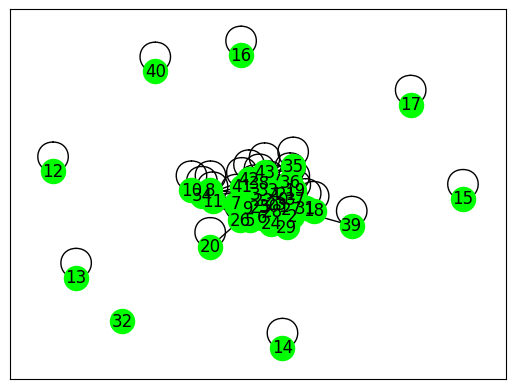

In [11]:
similarity_graph = networkx.from_numpy_array(similarity_matrix)
networkx.draw_networkx(similarity_graph, node_color='lime')

In [12]:
scores = networkx.pagerank(similarity_graph)
ranked_sentences = sorted(
  ((score, index) for index, score in scores.items()),
  reverse=True
)
ranked_sentences[:10]

[(0.03397205627653636, 22),
 (0.033052737508157286, 25),
 (0.030296981180502315, 27),
 (0.02985899163682161, 23),
 (0.029234590807844497, 30),
 (0.028873304966806408, 0),
 (0.027337570271924235, 28),
 (0.02666505614451879, 26),
 (0.026119918271341844, 7),
 (0.025802216125063497, 9)]

In [19]:
num_sentences = 6

top_sentence_indices = [
    ranked_sentences[index][1] for index in range(num_sentences)
]
top_sentence_indices.sort()

summary = ' '.join(np.array(sentences)[top_sentence_indices])
print('\n'.join(wrap(summary, 90)))

Comedian Joan Rivers died of "therapeutic complications" during a procedure to evaluate
her "voice changes" and stomach reflux, the New York medical examiner said Thursday.
Several clinic workers told investigators that the August   appointment began with Rivers'
personal throat doctor, Dr. Gwen Korovin, performing a laryngoscopy, which involves using
a device to view a patient's vocal folds, a source close to the investigation told CNN
last month. Gastroenterologist Dr. Lawrence Cohen, who was the medical director of the
clinic until resigning after Rivers' death, then performed an endoscopy intended to
diagnose why she was suffering a sore throat and hoarseness, the source said. Korovin then
began a second laryngoscopy to again view River's vocal cords, the source said. Korovin
was authorized only to observe Cohen, who performed the procedure, since she was not
certified by Yorkville Endoscopy clinic, as required by New York health law, the source
said. But Korovin denied "performing

## Display coincedence between the text and its summary

In [20]:
'''Find the matching substrings in 2 strings.
:parameter
    :param a: string - raw text
    :param b: string - raw text
:return
    2 lists used in to display matches
'''
def utils_split_sentences(a, b):
    ## find clean matches
    match = difflib.SequenceMatcher(isjunk=None, a=a, b=b, autojunk=True)
    lst_match = [block for block in match.get_matching_blocks() if block.size > 20]

    ## difflib didn't find any match
    if len(lst_match) == 0:
        lst_a, lst_b = nltk.sent_tokenize(a), nltk.sent_tokenize(b)

    ## work with matches
    else:
        first_m, last_m = lst_match[0], lst_match[-1]

        ### a
        string = a[0 : first_m.a]
        lst_a = [t for t in nltk.sent_tokenize(string)]
        for n in range(len(lst_match)):
            m = lst_match[n]
            string = a[m.a : m.a+m.size]
            lst_a.append(string)
            if n+1 < len(lst_match):
                next_m = lst_match[n+1]
                string = a[m.a+m.size : next_m.a]
                lst_a = lst_a + [t for t in nltk.sent_tokenize(string)]
            else:
                break
        string = a[last_m.a+last_m.size :]
        lst_a = lst_a + [t for t in nltk.sent_tokenize(string)]

        ### b
        string = b[0 : first_m.b]
        lst_b = [t for t in nltk.sent_tokenize(string)]
        for n in range(len(lst_match)):
            m = lst_match[n]
            string = b[m.b : m.b+m.size]
            lst_b.append(string)
            if n+1 < len(lst_match):
                next_m = lst_match[n+1]
                string = b[m.b+m.size : next_m.b]
                lst_b = lst_b + [t for t in nltk.sent_tokenize(string)]
            else:
                break
        string = b[last_m.b+last_m.size :]
        lst_b = lst_b + [t for t in nltk.sent_tokenize(string)]

    return lst_a, lst_b


'''
Highlights the matched strings in text.
:parameter
    :param a: string - raw text
    :param b: string - raw text
    :param both: bool - search a in b and, if True, viceversa
    :param sentences: bool - if False matches single words
:return
    text html, it can be visualized on notebook with display(HTML(text))
'''
def display_string_matching(a, b, both=True, sentences=True, titles=[]):
    if sentences is True:
        lst_a, lst_b = utils_split_sentences(a, b)
    else:
        lst_a, lst_b = a.split(), b.split()

    ## highlight a
    first_text = []
    for i in lst_a:
        if re.sub(r'[^\w\s]', '', i.lower()) in [re.sub(r'[^\w\s]', '', z.lower()) for z in lst_b]:
            first_text.append('<span style="background-color:rgba(255,215,0,0.3);">' + i + '</span>')
        else:
            first_text.append(i)
    first_text = ' '.join(first_text)

    ## highlight b
    second_text = []
    if both is True:
        for i in lst_b:
            if re.sub(r'[^\w\s]', '', i.lower()) in [re.sub(r'[^\w\s]', '', z.lower()) for z in lst_a]:
                second_text.append('<span style="background-color:rgba(255,215,0,0.3);">' + i + '</span>')
            else:
                second_text.append(i)
    else:
        second_text.append(b)
    second_text = ' '.join(second_text)

    ## concatenate
    if len(titles) > 0:
        first_text = "<strong>"+titles[0]+"</strong><br>"+first_text
    if len(titles) > 1:
        second_text = "<strong>"+titles[1]+"</strong><br>"+second_text
    else:
        second_text = "---"*65+"<br><br>"+second_text
    final_text = first_text +'<br><br>'+ second_text
    return final_text

In [21]:
text = ' '.join(norm_sentences)

highlight_match = display_string_matching(
    text, summary, both=True, sentences=False,
    titles=["Full Text", "Summary"]
)

display(HTML(highlight_match))